# Soil eDNA Metabarcoding Pipeline Analysis
### A Reproducible Workflow for MinION Amplicon Sequencing (JEDI & COI)
**Project:** Genorobotics Semester Project (EPFL)

**Markers:** JEDI (~460 bp COI, arthropod-optimized) & Standard COI (~658 bp Folmer)

---

## 0. Critical Review: Limitations & Technical Constraints

Before presenting the biological results, it is important to note the technical limitations encountered during this project.

### 1. The JEDI Advantage: Optimized for Soil Arthropods
The JEDI primers target a ~460 bp region of the COI gene, specifically designed for arthropod detection in environmental samples. This shorter fragment is better suited for degraded soil DNA compared to the standard Folmer COI primers (~658 bp).
* **Expected Dominance:** Arthropoda (insects, collembolans, arachnids), Annelida (earthworms), and Nematoda should dominate.
* **Potential Limitation:** The shorter fragment may reduce species-level resolution compared to full-length COI.

### 2. Standard COI in Soil: Expected Challenges
The standard Folmer COI primers (~658 bp) may underperform in soil matrices:
* **DNA Degradation:** Soil humic acids degrade DNA, favoring shorter amplicons (JEDI) over longer ones (COI).
* **Primer Bias:** Folmer primers were designed for a broader metazoan range but may miss soil-specific taxa that JEDI captures.

### 3. Taxonomic Gaps and Database Limitations
* **MIDORI2 Database:** Both markers use the MIDORI2 COI reference database for SINTAX-based taxonomy. MIDORI2 appends NCBI taxon IDs to names and uses rank prefixes — these are cleaned in the code below.
* **Confidence Threshold:** A strict 0.8 confidence threshold was applied. This ensures accuracy but increases the "Unassigned" rate, especially at lower taxonomic levels.
* **Local Gaps:** The database may lack sequences for many local soil invertebrates, leading to misidentifications or "Unassigned" labels.

### 4. Clustering and Size Selection
* **95% Identity Clustering:** Because Nanopore sequencing has a raw error rate of ~5%, clustering at 95% identity prevents sequencing errors from generating false OTUs.
* **Size Filters:** JEDI reads were filtered for ~300–600 bp; COI reads for ~500–800 bp. Reads outside these ranges are likely artifacts.

## To-Do List for Future Work
* **Build a local soil reference database:** Gather COI sequences for known local soil fauna from NCBI to improve species-level identification.
* **Compare JEDI vs COI yield:** Quantify how many more reads JEDI recovers from degraded soil DNA compared to standard COI.
* **Add blocking primers:** If plant or fungal DNA dominates, blocking primers could improve arthropod detection.
* **Optimize extraction protocols:** Test different soil DNA extraction kits to maximize invertebrate DNA yield.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from matplotlib import cm

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# Define a function to clean sample names (e.g., "Sample_barcode01" -> "01")
def clean_sample_names(columns):
    return [c.replace('Sample_barcode', '').replace('Sample_', '') for c in columns]

---
# Part A: JEDI Marker Biodiversity Analysis
*Objective: To characterize the soil invertebrate community structure using the JEDI marker (~460 bp COI), optimized for arthropod detection.*

## A.1a Broad Taxonomic Structure
This stacked bar chart visualizes the relative abundance of Phyla across all soil samples.
* **Expected Result:** We expect high abundances of **Arthropoda** (insects, collembolans, mites) and possibly **Annelida** (earthworms) and **Nematoda**.
* **Soil Signal:** Unlike water samples where Ciliophora dominates, soil samples should show a strong terrestrial invertebrate signal.

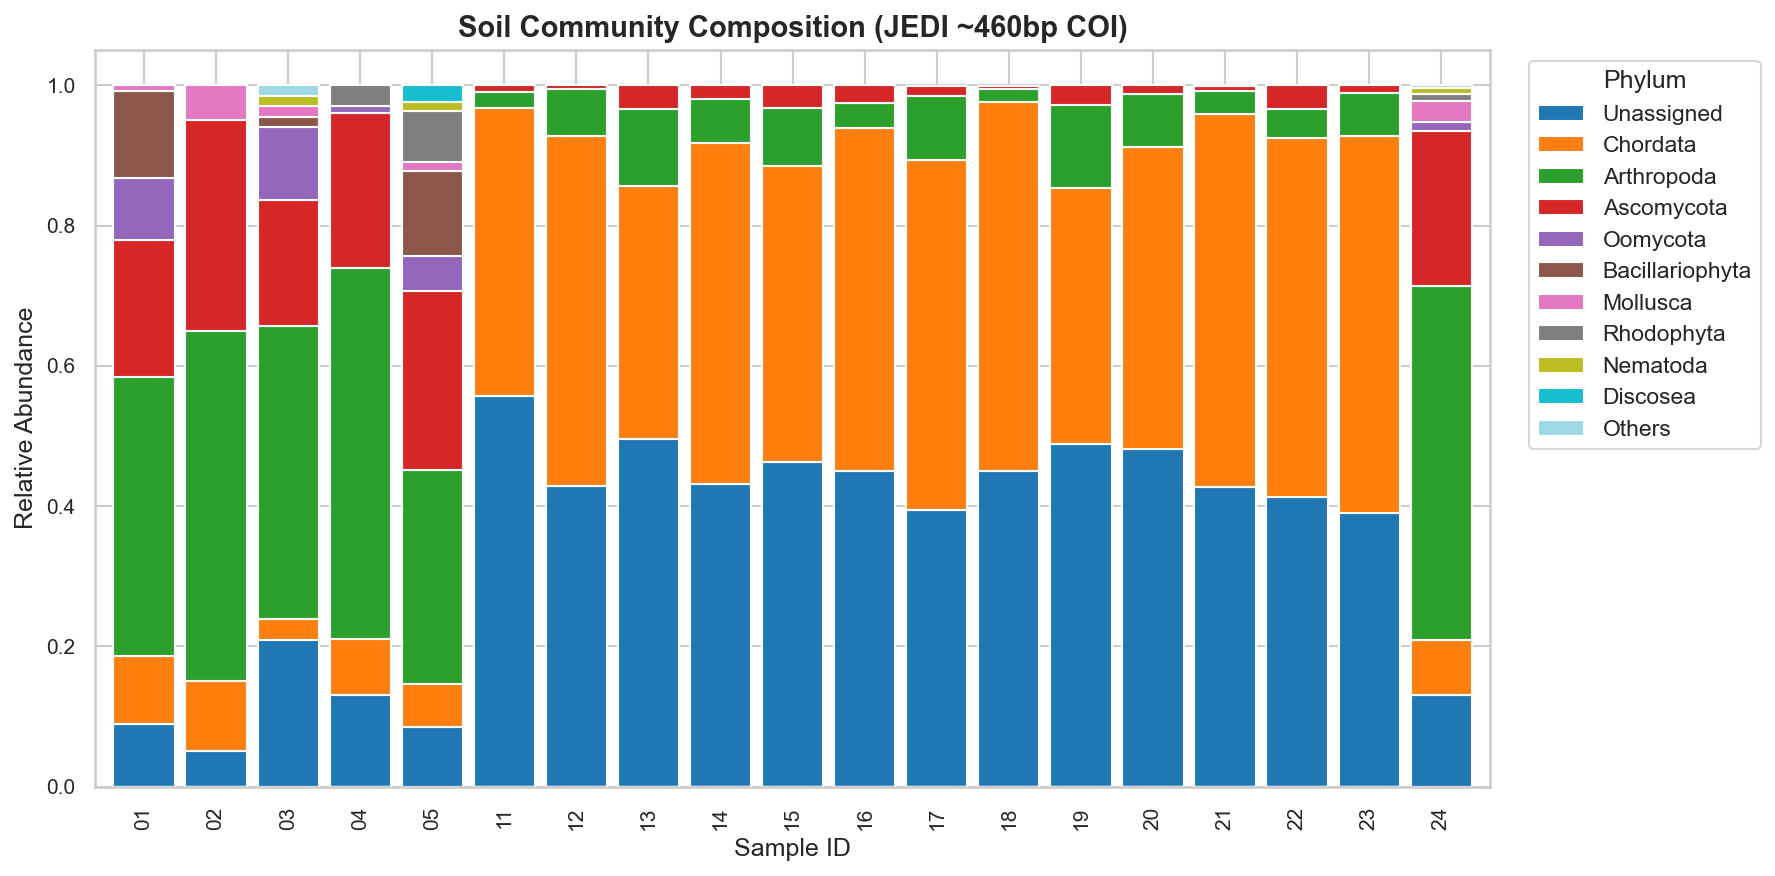

In [16]:
# Load JEDI Data
df_jedi = pd.read_csv('out/Soil_eDNA_JEDI_COI_14_01_26/taxonomy_summary/comprehensive_taxonomy_JEDI.csv')
sample_cols_jedi = [c for c in df_jedi.columns if c.startswith('Sample_') and 'unclassified' not in c]

# Clean MIDORI2 taxonomy labels
rank_prefixes = re.compile(r'^(kingdom|phylum|class|order|family|genus|species)_', re.IGNORECASE)
tax_levels = ['SILVA_Phylum', 'SILVA_Class', 'SILVA_Order', 'SILVA_Family', 'SILVA_Genus', 'SILVA_Species']
for col in tax_levels:
    if col in df_jedi.columns:
        df_jedi[col] = df_jedi[col].apply(
            lambda x: rank_prefixes.sub('', str(x)) if pd.notna(x) else x
        )
        df_jedi[col] = df_jedi[col].apply(
            lambda x: '_'.join(str(x).rsplit('_', 1)[:-1])
            if pd.notna(x) and '_' in str(x) and str(x).rsplit('_', 1)[-1].isdigit()
            else x
        )

# Group by Phylum
df_jedi['SILVA_Phylum'] = df_jedi['SILVA_Phylum'].fillna('Unassigned')
phylum_jedi = df_jedi.groupby('SILVA_Phylum')[sample_cols_jedi].sum()

# Sort and Group "Others"
phylum_jedi['Total'] = phylum_jedi.sum(axis=1)
phylum_jedi = phylum_jedi.sort_values('Total', ascending=False)
top_phyla = phylum_jedi.head(10).index

plot_data = phylum_jedi.loc[top_phyla].drop(columns='Total')
others = phylum_jedi.loc[~phylum_jedi.index.isin(top_phyla)].drop(columns='Total').sum()
plot_data.loc['Others'] = others

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
plot_data.columns = clean_sample_names(plot_data.columns)
plot_data.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, cmap='tab20')

ax.set_title('Soil Community Composition (JEDI ~460bp COI)', fontweight='bold')
ax.set_xlabel('Sample ID')
ax.set_ylabel('Relative Abundance')
ax.legend(title='Phylum', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

## A.1b Family-Level Breakdown (JEDI)
**Objective:** To see which specific biological families dominate within the broad Phyla.

**Visual Analysis:**
1. **Arthropod Families:** Look for soil-dwelling arthropod families such as Collembola-related families, mite families (Oribatida), and insect larvae families.
2. **The "Unassigned" Gap:** A large "Unassigned" component is expected because the MIDORI2 database may lack Family-level resolution for many soil invertebrates.
3. **Annelid Families:** Check for **Lumbricidae** (earthworms) — their presence validates the soil sampling quality.

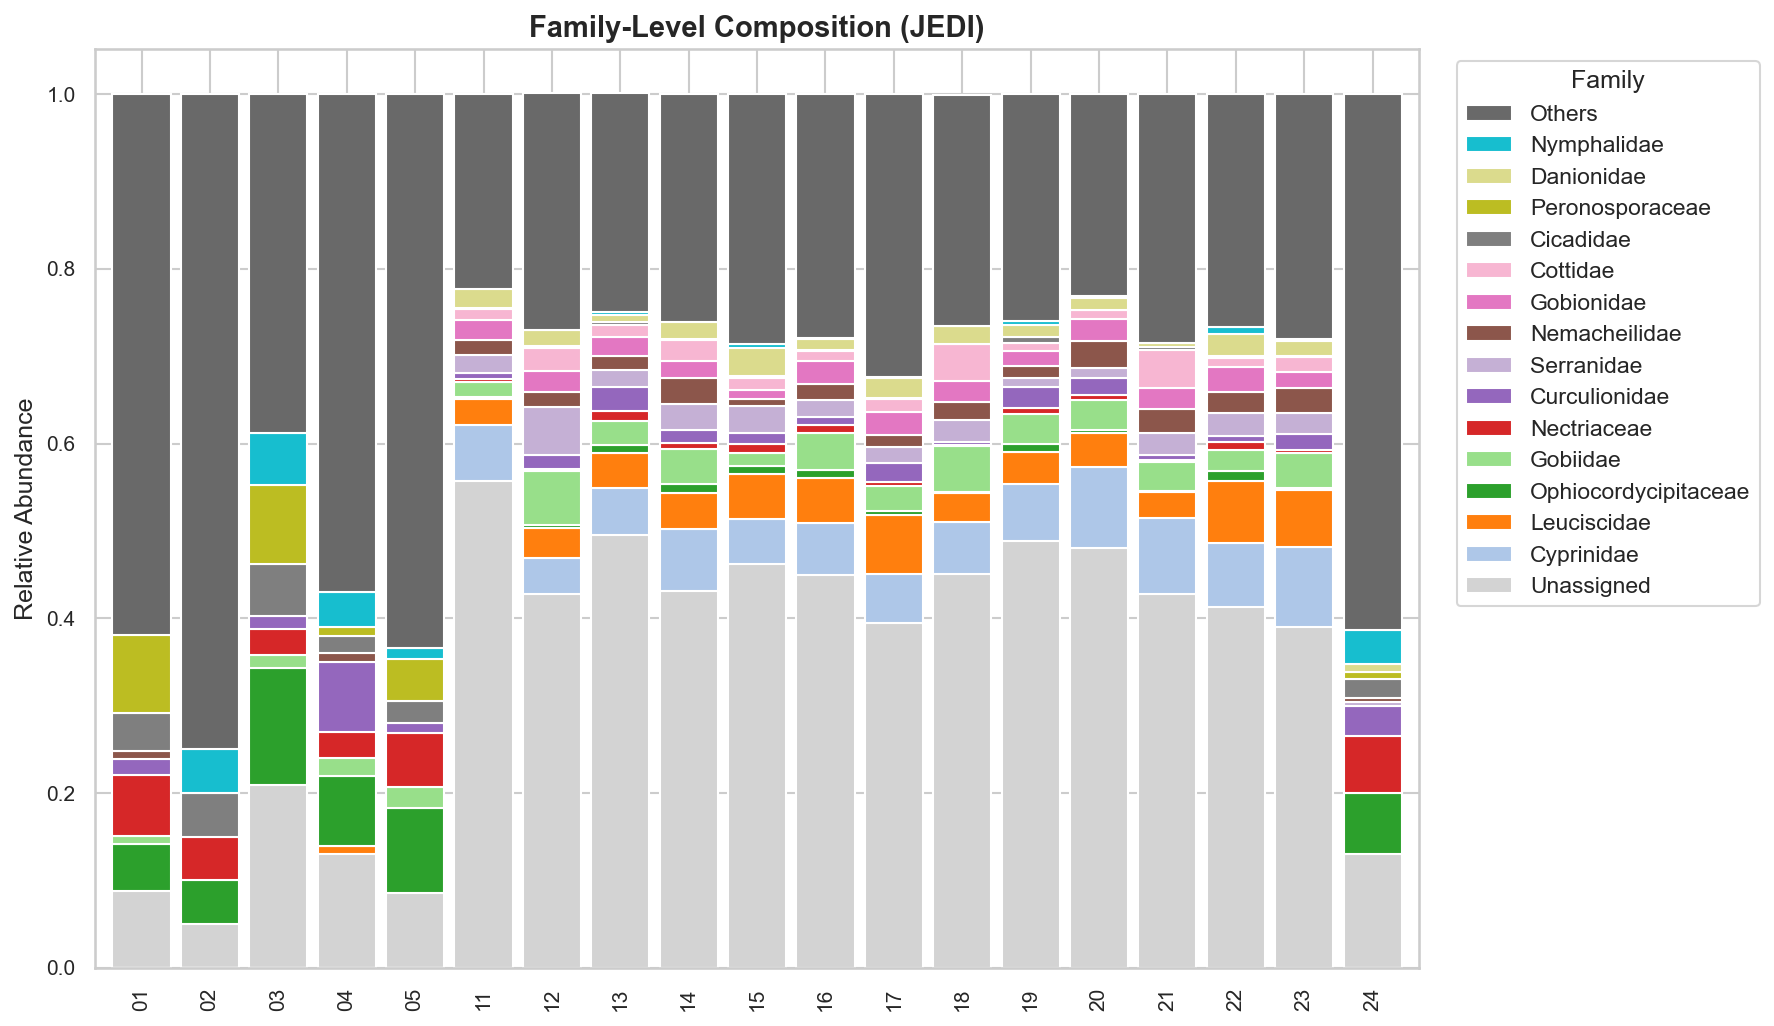

In [17]:
# Group by Family (JEDI)
df_jedi['SILVA_Family'] = df_jedi['SILVA_Family'].fillna('Unassigned')
family_jedi = df_jedi.groupby('SILVA_Family')[sample_cols_jedi].sum()

# Sort and Top 15
family_jedi['Total'] = family_jedi.sum(axis=1)
family_jedi = family_jedi.sort_values('Total', ascending=False)
top_families = family_jedi.head(15).index

# Prepare Data
plot_fam = family_jedi.loc[top_families].drop(columns='Total')
others_fam = family_jedi.loc[~family_jedi.index.isin(top_families)].drop(columns='Total').sum()
plot_fam.loc['Others'] = others_fam

# Custom color logic
num_colors = len(plot_fam)
colors = cm.tab20(np.linspace(0, 1, num_colors))

custom_colors = []
for i, family_name in enumerate(plot_fam.index):
    if family_name == 'Unassigned':
        custom_colors.append('#D3D3D3')
    elif family_name == 'Others':
        custom_colors.append('#696969')
    else:
        custom_colors.append(colors[i])

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
plot_fam.columns = clean_sample_names(plot_fam.columns)
plot_fam.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, color=custom_colors)

ax.set_title('Family-Level Composition (JEDI)', fontweight='bold')
ax.set_ylabel('Relative Abundance')
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), bbox_to_anchor=(1.02, 1), loc='upper left', title='Family')

plt.tight_layout()
plt.show()

## A.2 Dominant Taxa: Genus Level Analysis (JEDI)
**Question:** Which specific organisms are driving the biological signal in the soil?

Here we check which genera the JEDI primers captured most effectively.
* **Key Targets:** We look for soil arthropod genera (collembolans, mites, beetle larvae) and annelid genera.
* **Database Limitation:** Some genera may appear as close relatives from the MIDORI2 database rather than the exact local species.

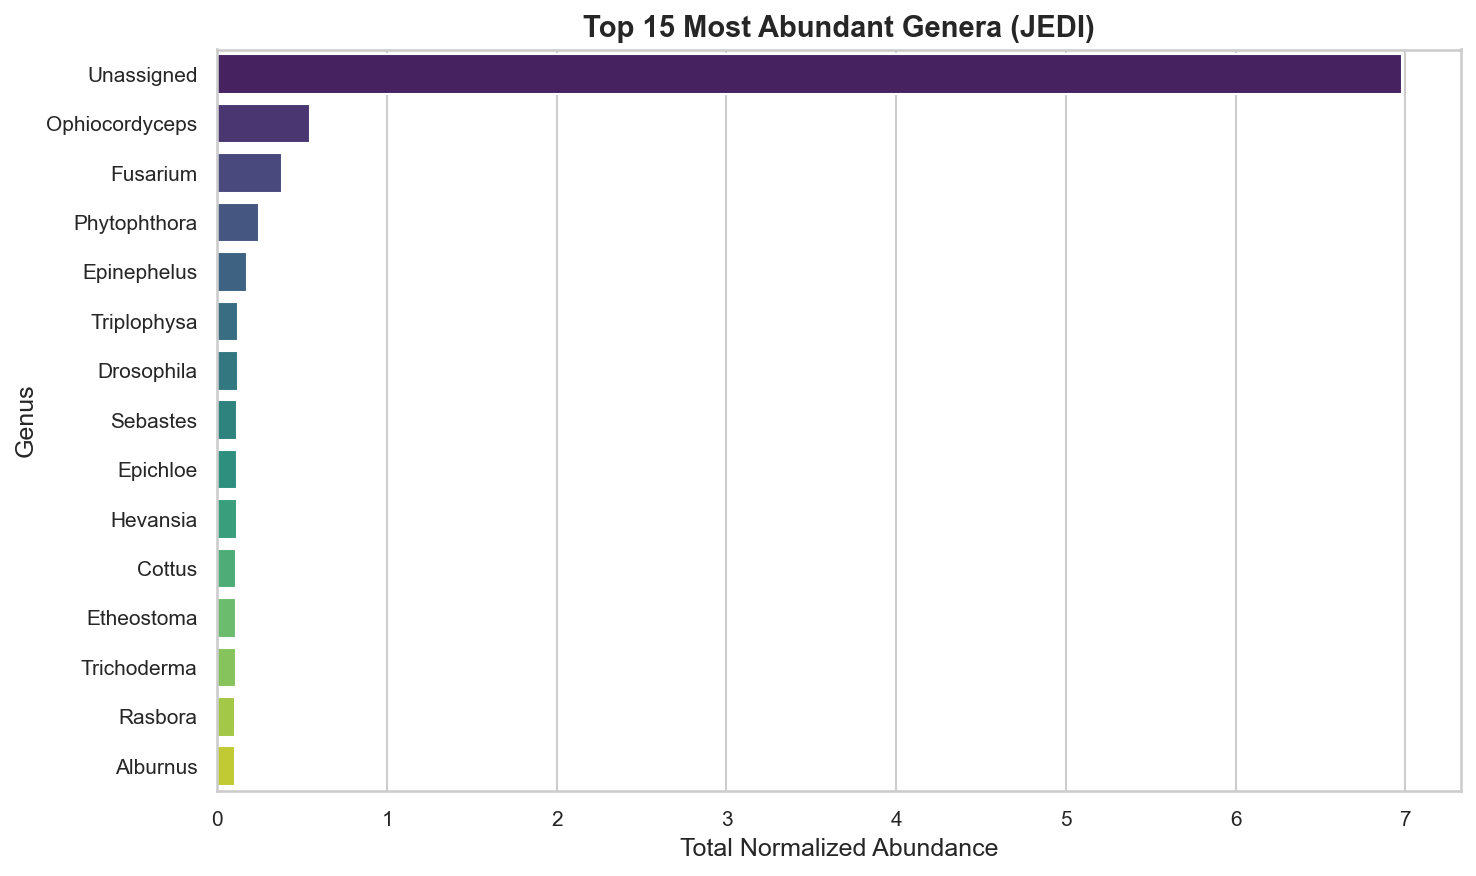

In [18]:
# Group by Genus (JEDI)
df_jedi['SILVA_Genus'] = df_jedi['SILVA_Genus'].fillna('Unassigned')
genus_jedi = df_jedi.groupby('SILVA_Genus')['Total_Abundance'].sum().sort_values(ascending=False).head(15)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=genus_jedi.values, y=genus_jedi.index, hue=genus_jedi.index, palette="viridis", ax=ax, legend=False)

ax.set_title('Top 15 Most Abundant Genera (JEDI)', fontweight='bold')
ax.set_xlabel('Total Normalized Abundance')
ax.set_ylabel('Genus')

plt.tight_layout()
plt.show()

## A.3 Detailed Identification: Top 20 Species (JEDI)
**Objective:** To get the most granular identification possible at the Species level.

**MIDORI2 Limitation:** MIDORI2's SINTAX output often provides only genus-level names in the species field. Many JEDI "species" assignments may be identical to their genus. For true species-level identification, BLAST validation (Section B.5) is required.

**Why is "Unassigned" expected to dominate?**
1. Many assignments fell below the 0.8 confidence threshold.
2. The database lacks many local soil invertebrate species.
3. The shorter JEDI fragment (~460 bp) may reduce species-level resolution.

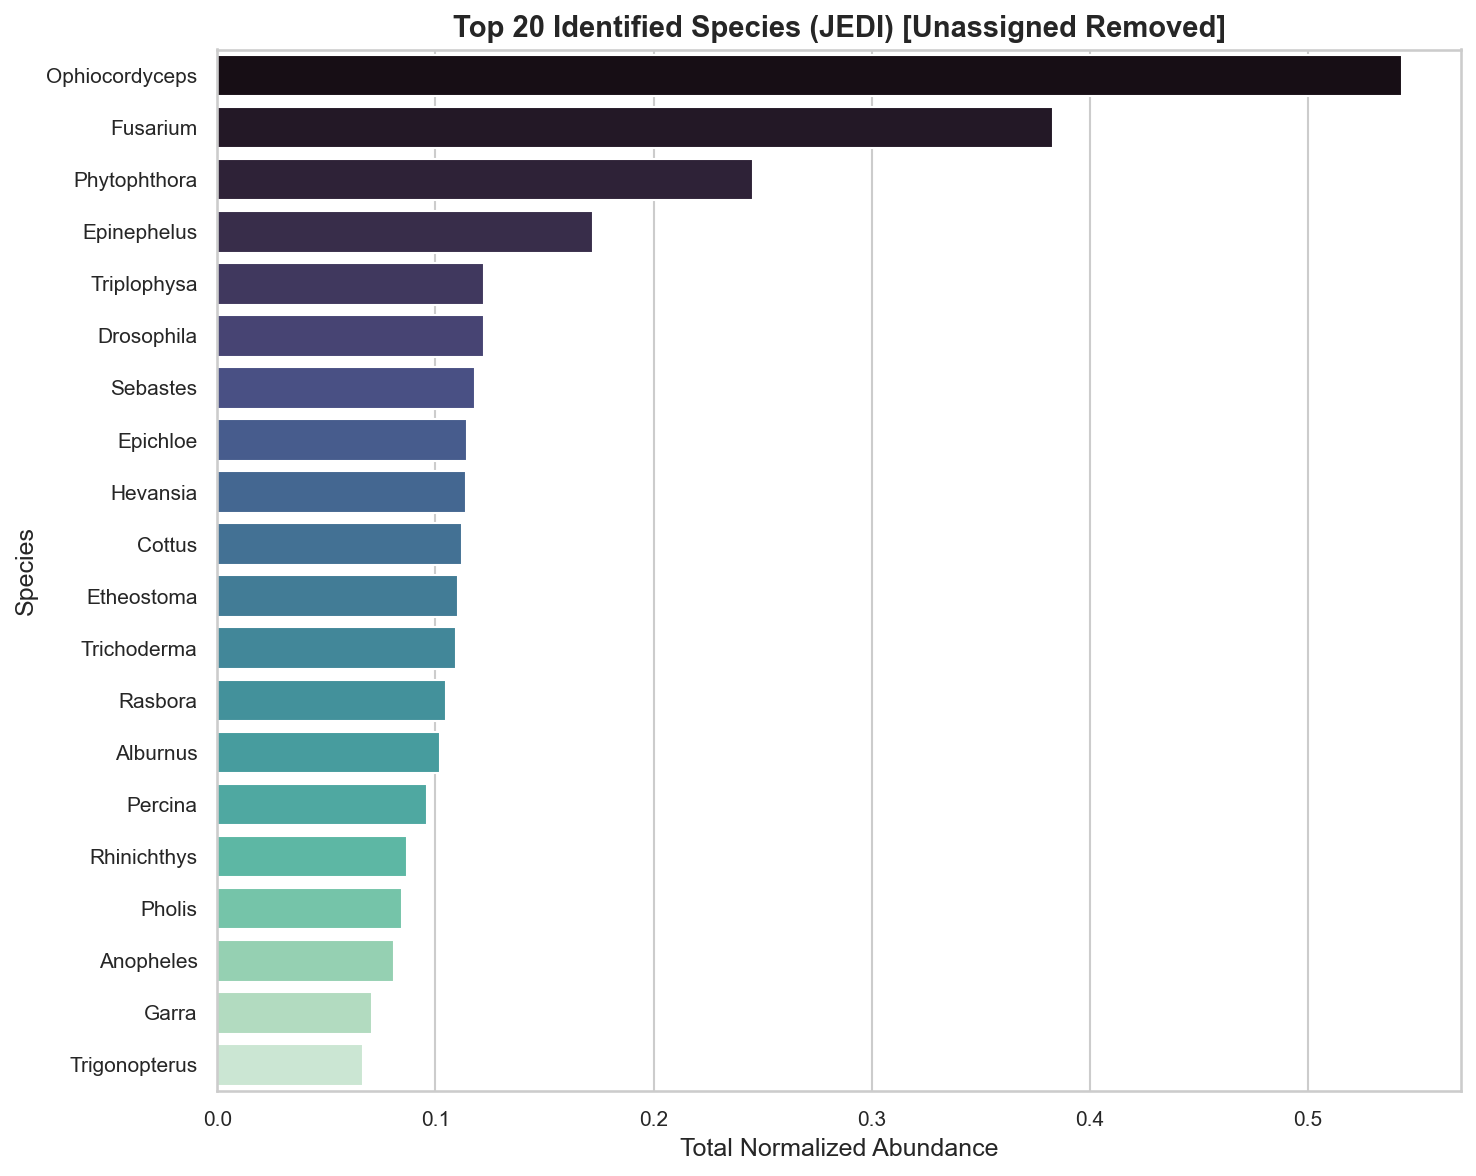

In [19]:
# Group by Species (JEDI)
df_jedi['SILVA_Species'] = df_jedi['SILVA_Species'].fillna('Unassigned')

# Sum abundance
species_jedi = df_jedi.groupby('SILVA_Species')['Total_Abundance'].sum()
species_jedi = species_jedi.sort_values(ascending=False)

# FILTER: Remove 'Unassigned' to focus on identified species
species_jedi_clean = species_jedi.drop('Unassigned', errors='ignore').head(20)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=species_jedi_clean.values, y=species_jedi_clean.index, hue=species_jedi_clean.index, palette="mako", ax=ax, legend=False)

ax.set_title('Top 20 Identified Species (JEDI) [Unassigned Removed]', fontweight='bold')
ax.set_xlabel('Total Normalized Abundance')
ax.set_ylabel('Species')

plt.tight_layout()
plt.show()

## A.4 The "Unassigned" Reality Check (JEDI)
**Limitation:** A significant portion of reads may remain "Unassigned," especially at lower taxonomic levels.

**Why does this happen?**
1. **Database Gaps:** MIDORI2 lacks many soil invertebrate sequences, especially for local Swiss fauna.
2. **Strict Thresholds:** The 0.8 confidence threshold means uncertain assignments are marked "Unassigned" rather than guessed.
3. **Methodological Choice:** Accuracy over coverage — better to label a sequence as unknown than provide a false identification.

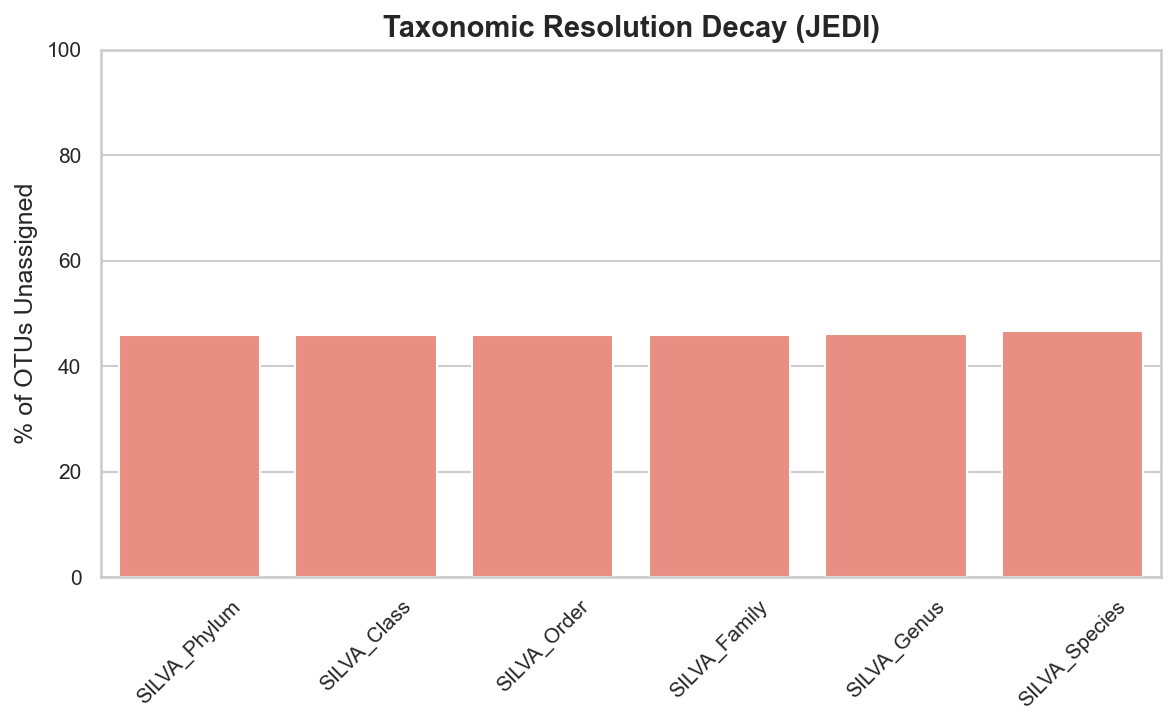

In [20]:
# Calculate % Unassigned at each level (JEDI)
levels = ['SILVA_Phylum', 'SILVA_Class', 'SILVA_Order', 'SILVA_Family', 'SILVA_Genus', 'SILVA_Species']
unassigned_counts_jedi = []

for level in levels:
    n_unassigned = df_jedi[level].isin(['Unassigned', np.nan]).sum()
    pct = (n_unassigned / len(df_jedi)) * 100
    unassigned_counts_jedi.append(pct)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=levels, y=unassigned_counts_jedi, color="salmon")
plt.title('Taxonomic Resolution Decay (JEDI)', fontweight='bold')
plt.ylabel('% of OTUs Unassigned')
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

---
# Part B: COI Marker Biodiversity Analysis (Standard Folmer ~658 bp)
*Objective: To characterize the soil community using the standard COI marker and compare its performance with the JEDI marker in a soil matrix.*

**Technical Context:** The standard Folmer COI primers (~658 bp) target a broader range of metazoans but require longer intact DNA fragments. In soil, where DNA degradation is common, this marker may underperform compared to JEDI.

## B.1a Broad Taxonomic Structure (COI)
This stacked bar chart visualizes the relative abundance of Phyla across all soil samples using the standard COI marker.
* **Expected Result:** Similar taxa to JEDI but potentially with fewer reads due to DNA degradation favoring shorter fragments.
* **Comparison:** Differences between JEDI and COI compositions may reveal primer bias or DNA quality effects.

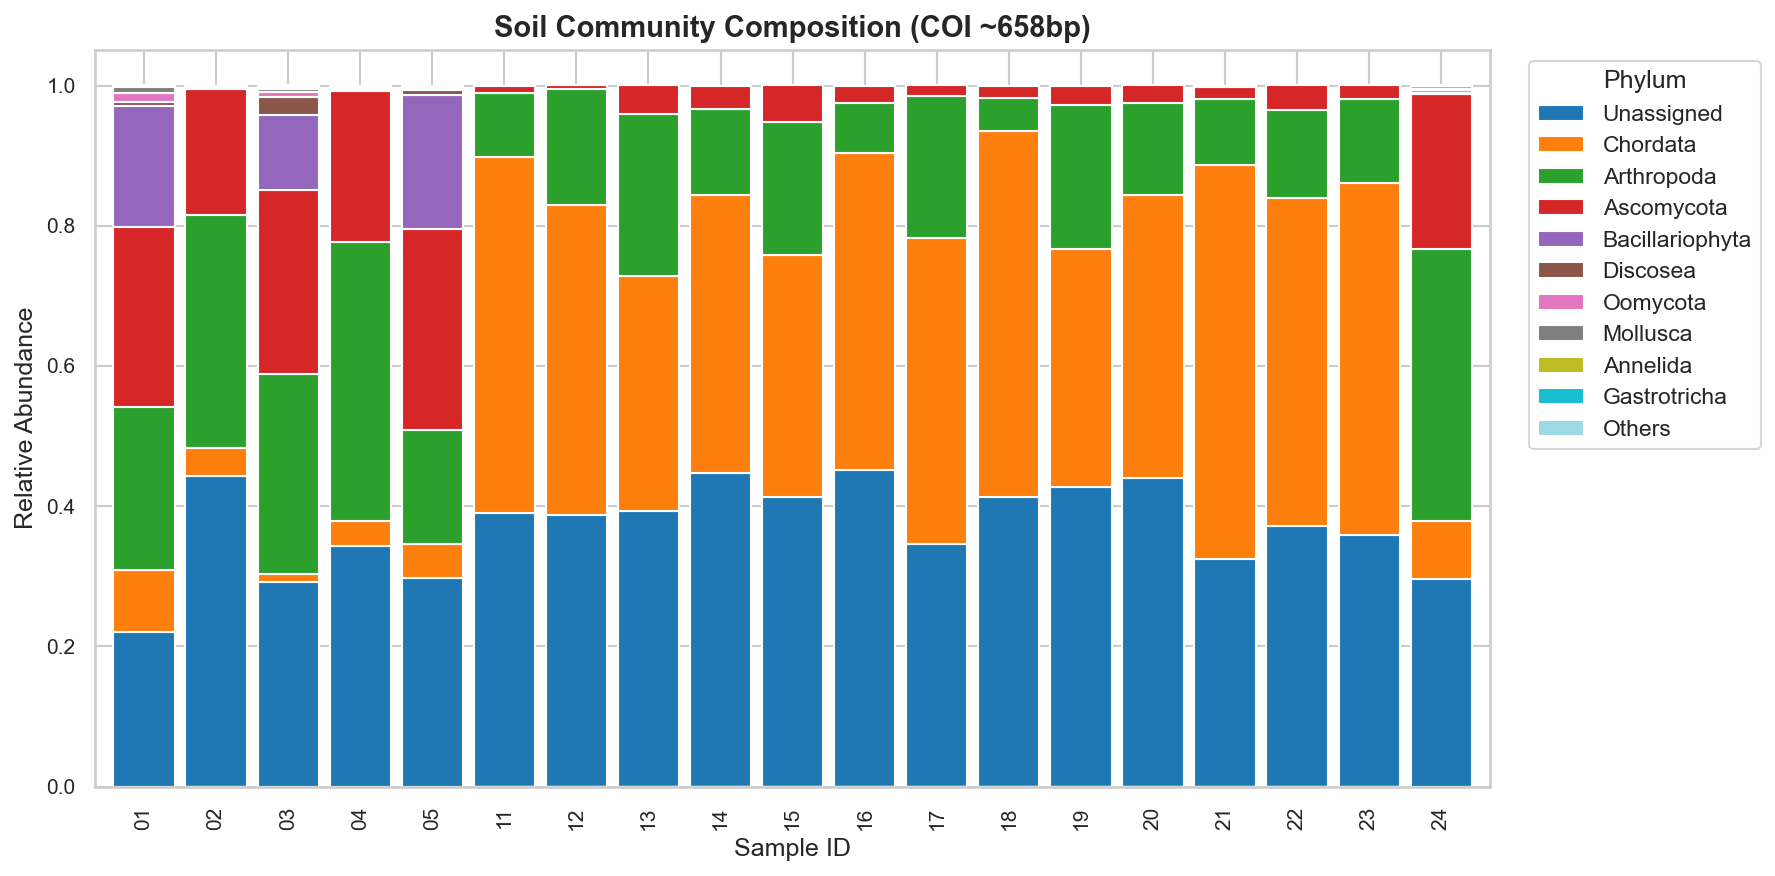

In [21]:
# Load COI Data
df_coi = pd.read_csv('out/Soil_eDNA_JEDI_COI_14_01_26/taxonomy_summary/comprehensive_taxonomy_COI.csv')
sample_cols_coi = [c for c in df_coi.columns if c.startswith('Sample_') and 'unclassified' not in c]

# Clean MIDORI2 taxonomy labels
for col in tax_levels:
    if col in df_coi.columns:
        df_coi[col] = df_coi[col].apply(
            lambda x: rank_prefixes.sub('', str(x)) if pd.notna(x) else x
        )
        df_coi[col] = df_coi[col].apply(
            lambda x: '_'.join(str(x).rsplit('_', 1)[:-1])
            if pd.notna(x) and '_' in str(x) and str(x).rsplit('_', 1)[-1].isdigit()
            else x
        )

# Group by Phylum
df_coi['SILVA_Phylum'] = df_coi['SILVA_Phylum'].fillna('Unassigned')
phylum_coi = df_coi.groupby('SILVA_Phylum')[sample_cols_coi].sum()

# Sort and Group "Others"
phylum_coi['Total'] = phylum_coi.sum(axis=1)
phylum_coi = phylum_coi.sort_values('Total', ascending=False)
top_phyla_coi = phylum_coi.head(10).index

plot_data_coi = phylum_coi.loc[top_phyla_coi].drop(columns='Total')
others_coi = phylum_coi.loc[~phylum_coi.index.isin(top_phyla_coi)].drop(columns='Total').sum()
plot_data_coi.loc['Others'] = others_coi

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
plot_data_coi.columns = clean_sample_names(plot_data_coi.columns)
plot_data_coi.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, cmap='tab20')

ax.set_title('Soil Community Composition (COI ~658bp)', fontweight='bold')
ax.set_xlabel('Sample ID')
ax.set_ylabel('Relative Abundance')
ax.legend(title='Phylum', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

## B.1b Family-Level Breakdown (COI)
**Objective:** To see which specific biological families dominate within the broad Phyla for the standard COI marker.

**Visual Analysis:**
1. **Comparison with JEDI:** Do the same families appear, or does the longer COI fragment capture different taxa?
2. **The "Unassigned" Gap:** Due to the potentially lower sequencing depth (DNA degradation), we expect a significant "Unassigned" fraction.
3. **Novel Families:** The broader primer range of Folmer COI may capture some families that JEDI misses.

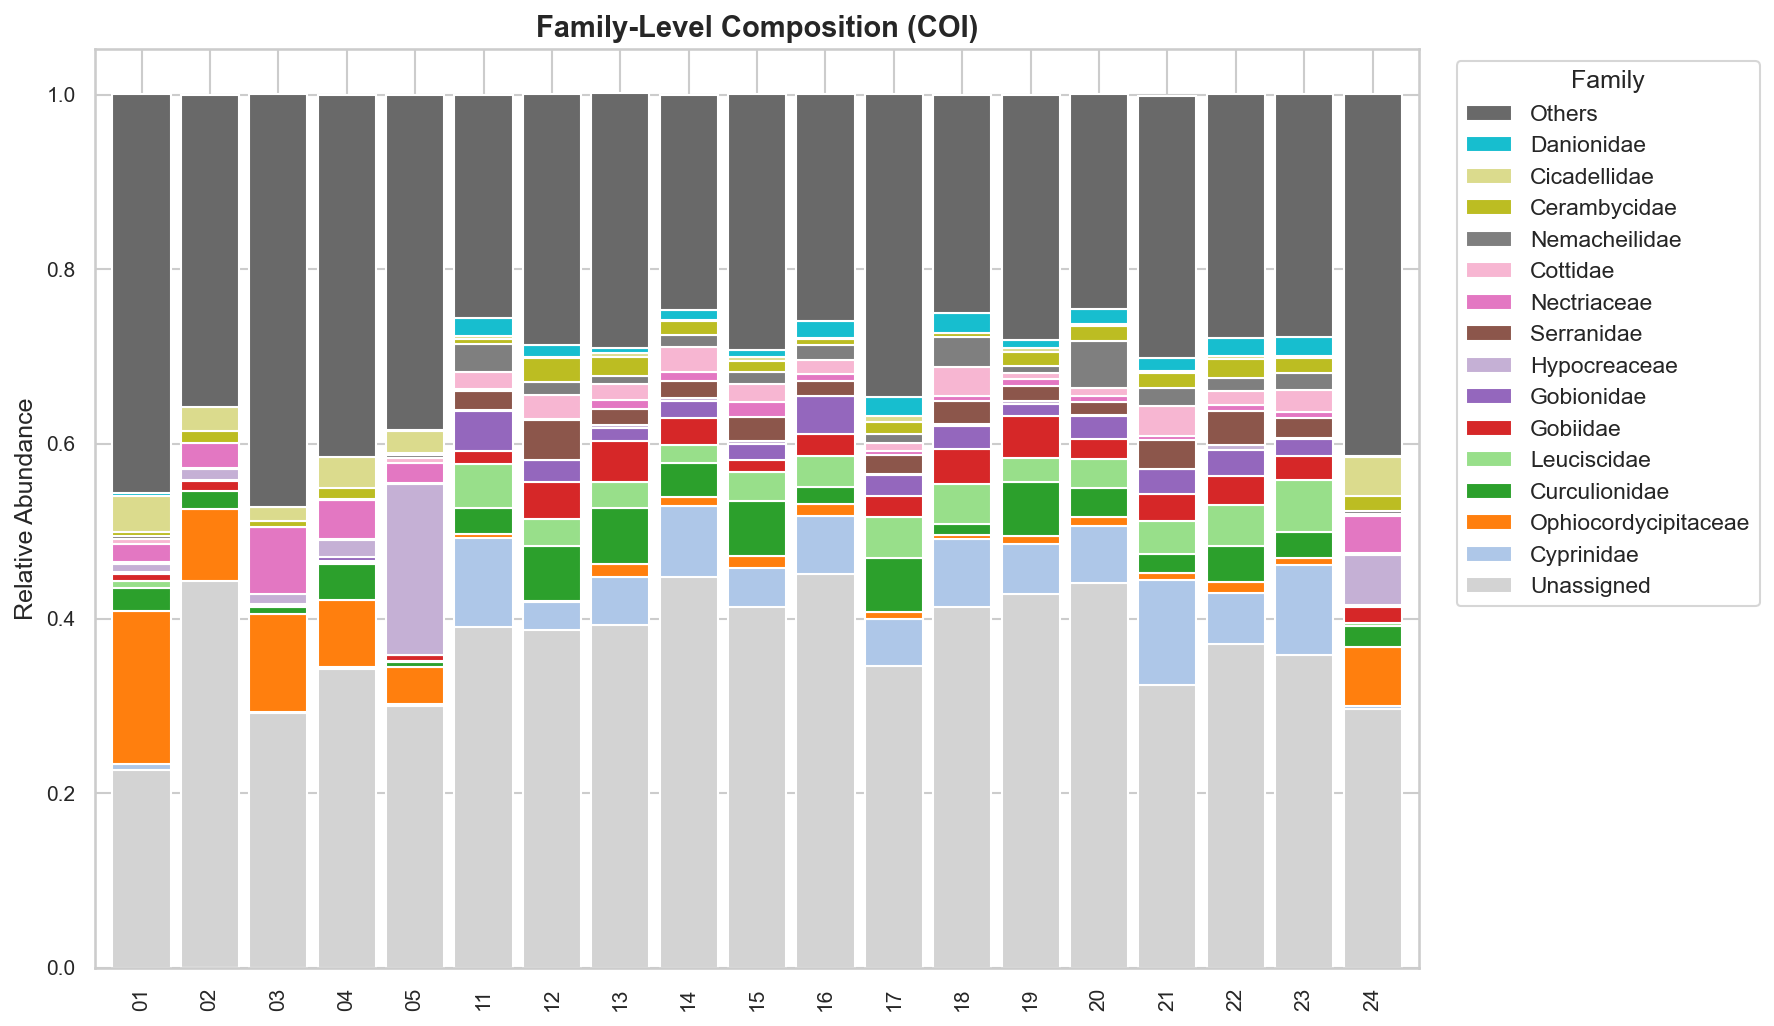

In [22]:
# Group by Family (COI)
df_coi['SILVA_Family'] = df_coi['SILVA_Family'].fillna('Unassigned')
family_coi = df_coi.groupby('SILVA_Family')[sample_cols_coi].sum()

# Sort and Top 15
family_coi['Total'] = family_coi.sum(axis=1)
family_coi = family_coi.sort_values('Total', ascending=False)
top_families_coi = family_coi.head(15).index

# Prepare Data
plot_fam_coi = family_coi.loc[top_families_coi].drop(columns='Total')
others_fam_coi = family_coi.loc[~family_coi.index.isin(top_families_coi)].drop(columns='Total').sum()
plot_fam_coi.loc['Others'] = others_fam_coi

# Custom color logic
num_colors_coi = len(plot_fam_coi)
colors_coi = cm.tab20(np.linspace(0, 1, num_colors_coi))

custom_colors_coi = []
for i, family_name in enumerate(plot_fam_coi.index):
    if family_name == 'Unassigned':
        custom_colors_coi.append('#D3D3D3')
    elif family_name == 'Others':
        custom_colors_coi.append('#696969')
    else:
        custom_colors_coi.append(colors_coi[i])

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
plot_fam_coi.columns = clean_sample_names(plot_fam_coi.columns)
plot_fam_coi.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, color=custom_colors_coi)

ax.set_title('Family-Level Composition (COI)', fontweight='bold')
ax.set_ylabel('Relative Abundance')
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), bbox_to_anchor=(1.02, 1), loc='upper left', title='Family')

plt.tight_layout()
plt.show()

## B.2 Dominant Taxa: Genus Level Analysis (COI)
**Question:** Which specific organisms are driving the standard COI biological signal?

The standard COI marker has a broader primer range than JEDI. Here we check if it captured additional genera not seen in the JEDI results.
* **Key Comparison:** Do the top genera match the JEDI results, or does the longer fragment provide different community information?
* **Database Effect:** MIDORI2 may resolve some genera better with the longer ~658 bp fragment.

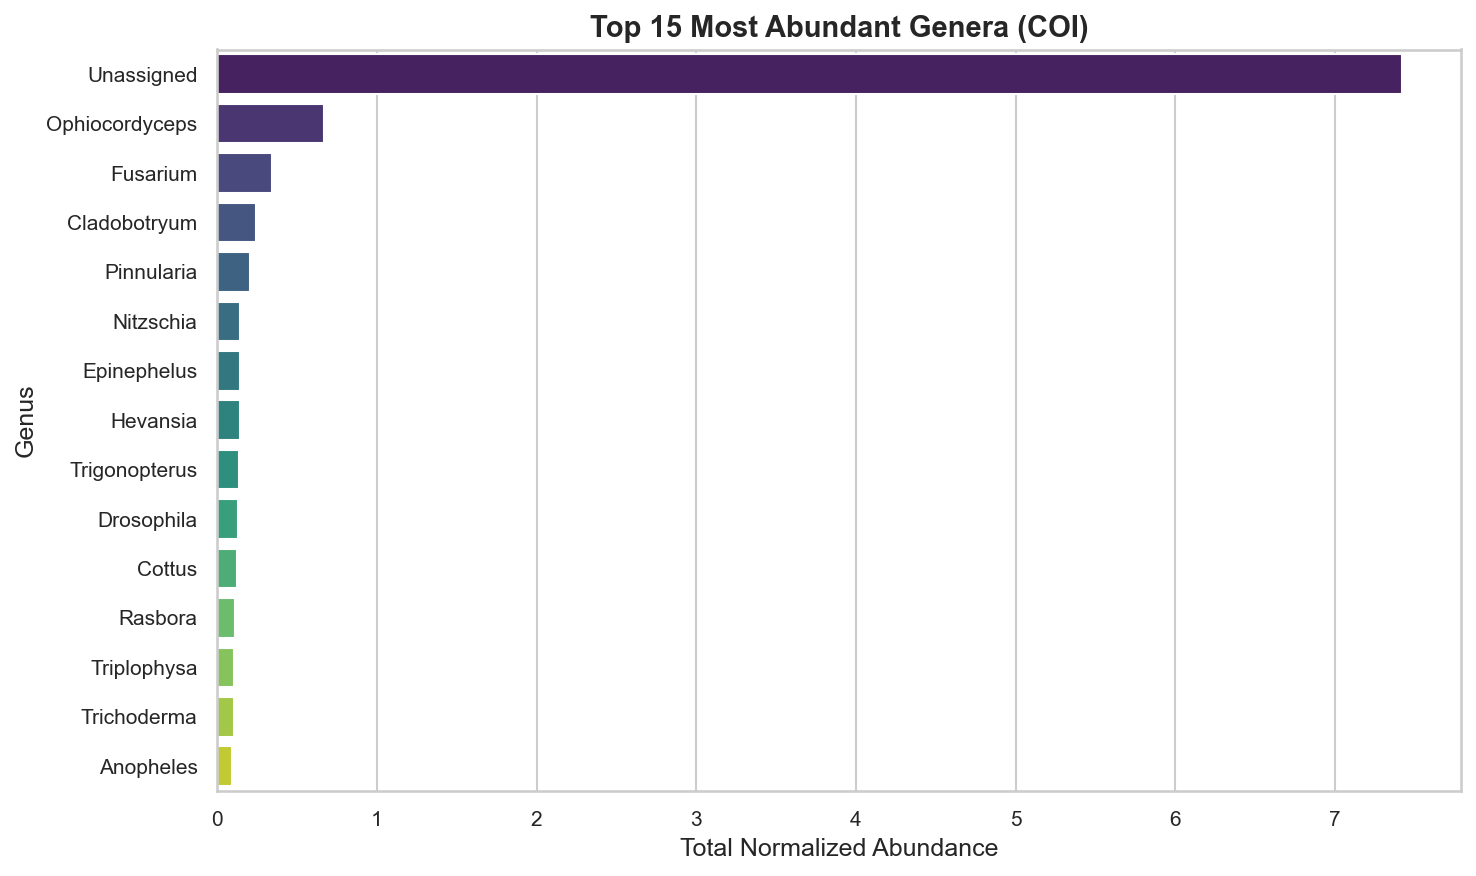

In [23]:
# Group by Genus (COI)
df_coi['SILVA_Genus'] = df_coi['SILVA_Genus'].fillna('Unassigned')
genus_coi = df_coi.groupby('SILVA_Genus')['Total_Abundance'].sum().sort_values(ascending=False).head(15)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=genus_coi.values, y=genus_coi.index, hue=genus_coi.index, palette="viridis", ax=ax, legend=False)

ax.set_title('Top 15 Most Abundant Genera (COI)', fontweight='bold')
ax.set_xlabel('Total Normalized Abundance')
ax.set_ylabel('Genus')

plt.tight_layout()
plt.show()

## B.3 Detailed Identification: Top 20 Species (COI)
**Objective:** To get the most granular identification possible at the Species level from the standard COI marker.

**MIDORI2 Limitation:** As with JEDI, MIDORI2's SINTAX output often retains only the genus name in the species field. The longer COI fragment should theoretically improve species discrimination, but this depends on the database completeness for local soil fauna.

**Comparison with JEDI:** If both markers identify the same top species, it increases confidence in those identifications. Unique species found by one marker but not the other may indicate primer bias.

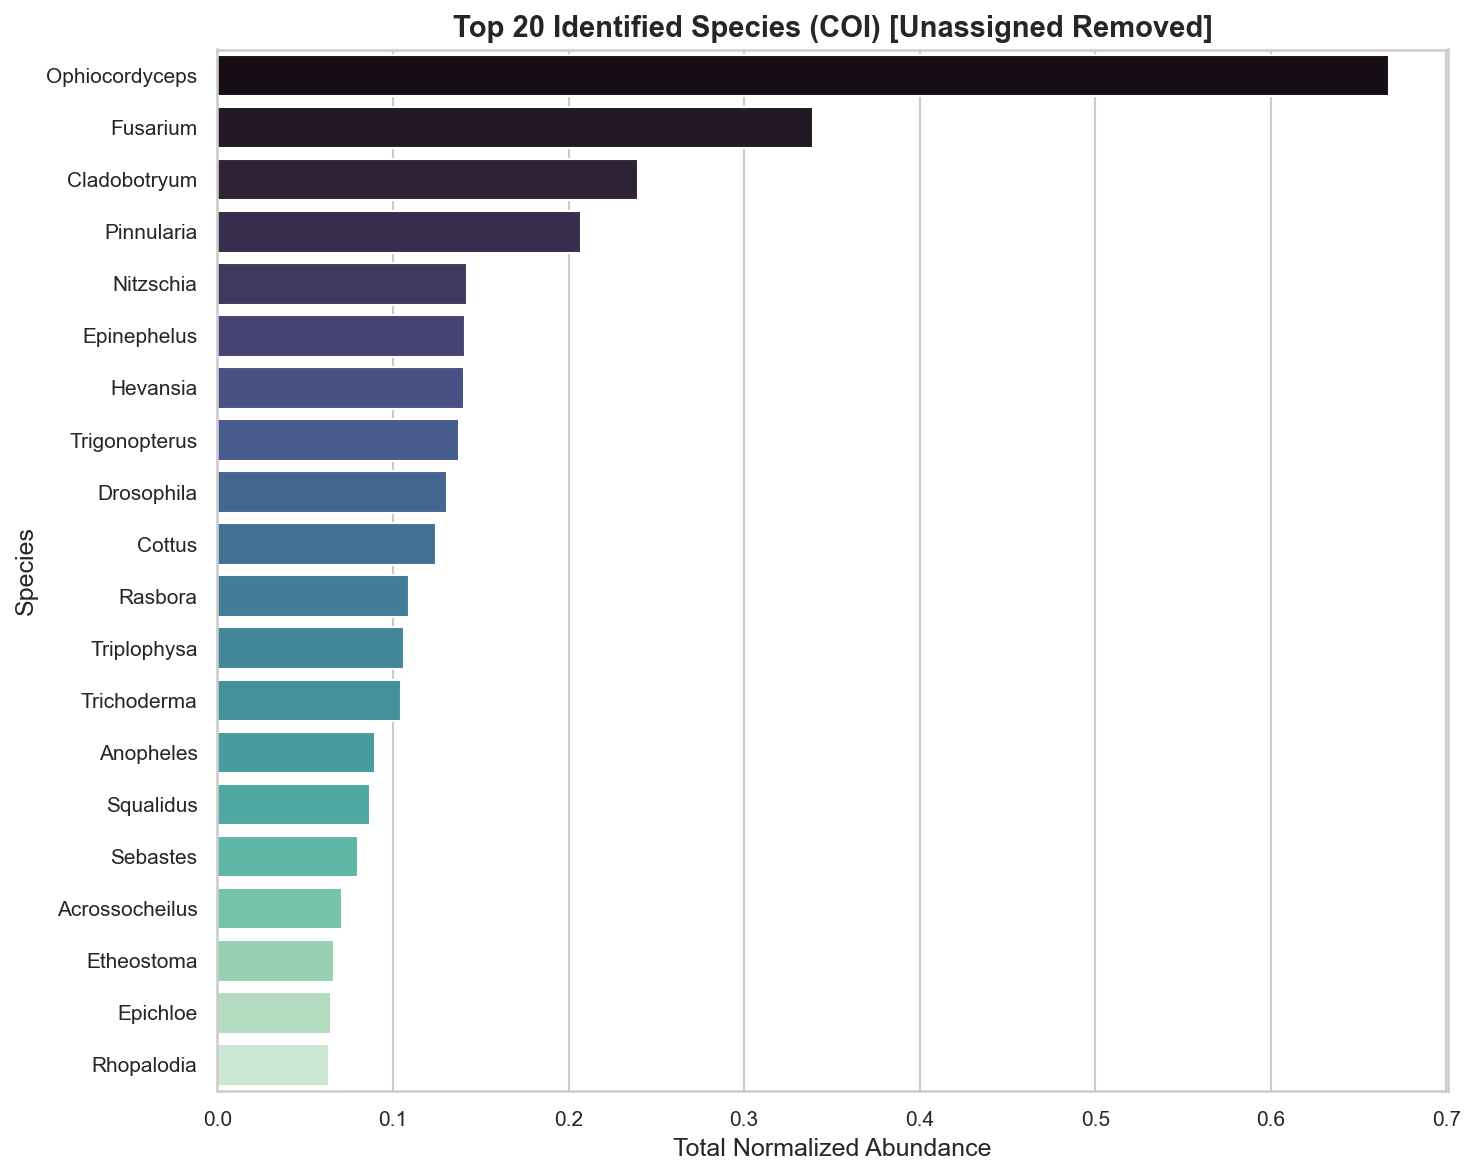

In [24]:
# Group by Species (COI)
df_coi['SILVA_Species'] = df_coi['SILVA_Species'].fillna('Unassigned')

# Sum abundance
species_coi = df_coi.groupby('SILVA_Species')['Total_Abundance'].sum()
species_coi = species_coi.sort_values(ascending=False)

# FILTER: Remove 'Unassigned' to focus on identified species
species_coi_clean = species_coi.drop('Unassigned', errors='ignore').head(20)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=species_coi_clean.values, y=species_coi_clean.index, hue=species_coi_clean.index, palette="mako", ax=ax, legend=False)

ax.set_title('Top 20 Identified Species (COI) [Unassigned Removed]', fontweight='bold')
ax.set_xlabel('Total Normalized Abundance')
ax.set_ylabel('Species')

plt.tight_layout()
plt.show()

## B.4 Taxonomic Resolution Comparison: JEDI vs COI
**Comparison:** We expect the JEDI marker to have a different "Unassigned" profile than standard COI. Key questions:
1. Does the shorter JEDI fragment lead to more or fewer unassigned OTUs?
2. At which taxonomic levels do the markers diverge most?
3. Does either marker provide consistently better resolution for soil taxa?

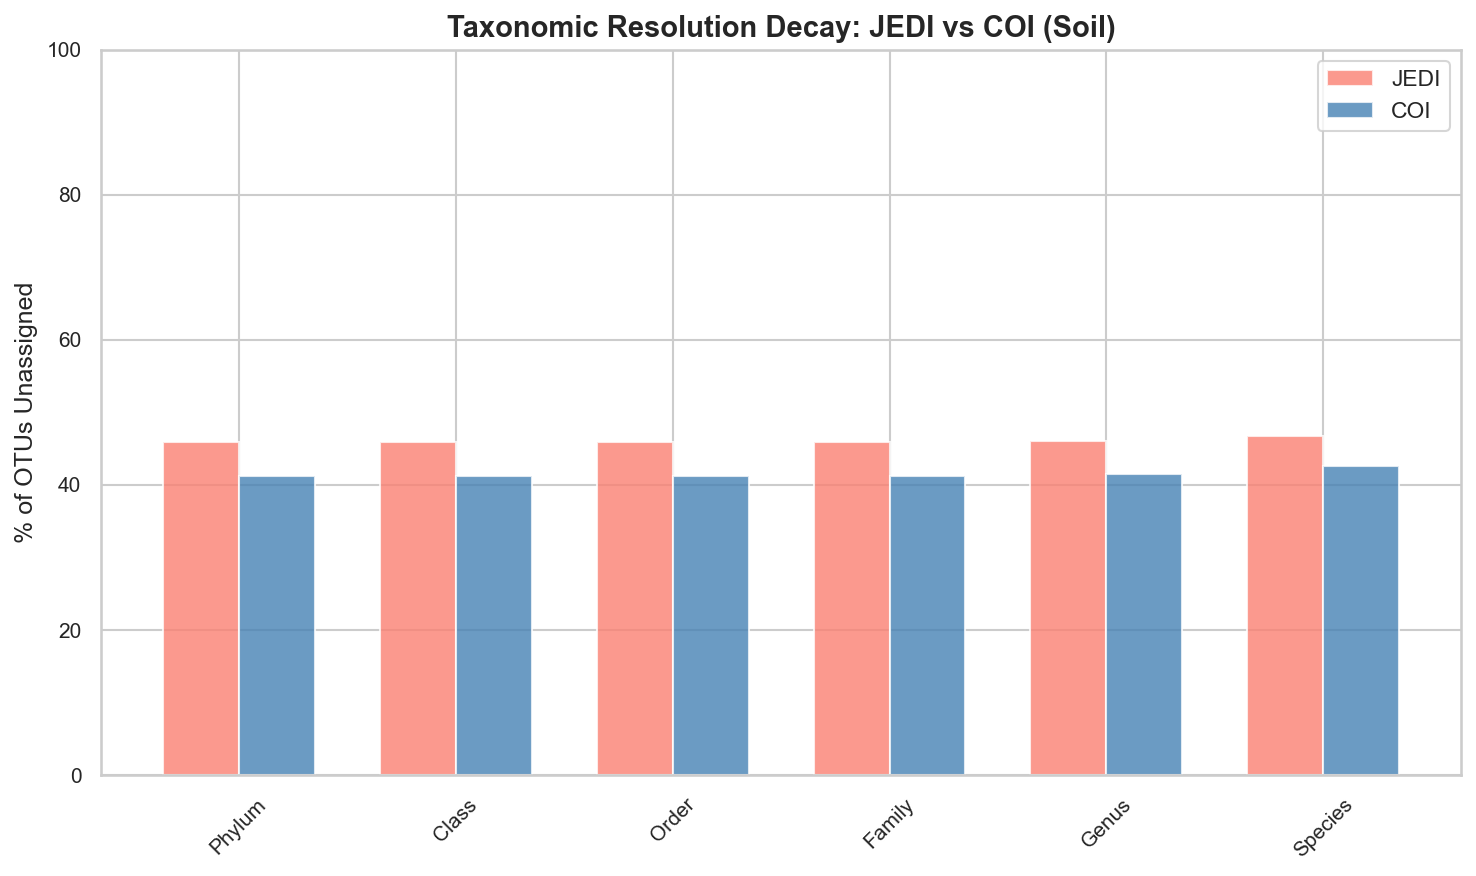

In [25]:
# Calculate % Unassigned at each level for both markers
levels = ['SILVA_Phylum', 'SILVA_Class', 'SILVA_Order', 'SILVA_Family', 'SILVA_Genus', 'SILVA_Species']

# Recalculate JEDI unassigned for comparison
unassigned_jedi = []
for level in levels:
    n_unassigned = df_jedi[level].isin(['Unassigned', np.nan]).sum()
    pct = (n_unassigned / len(df_jedi)) * 100
    unassigned_jedi.append(pct)

unassigned_coi = []
for level in levels:
    n_unassigned = df_coi[level].isin(['Unassigned', np.nan]).sum()
    pct = (n_unassigned / len(df_coi)) * 100
    unassigned_coi.append(pct)

# Plot: side-by-side comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(levels))
width = 0.35

bars1 = ax.bar(x - width/2, unassigned_jedi, width, label='JEDI', color='salmon', alpha=0.8)
bars2 = ax.bar(x + width/2, unassigned_coi, width, label='COI', color='steelblue', alpha=0.8)

ax.set_title('Taxonomic Resolution Decay: JEDI vs COI (Soil)', fontweight='bold')
ax.set_ylabel('% of OTUs Unassigned')
ax.set_xticks(x)
ax.set_xticklabels([l.replace('SILVA_', '') for l in levels], rotation=45)
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
plt.show()

## B.5 Forensics: Manual BLAST Identification
BLAST validation of the top OTUs provides ground-truth species identification beyond what SINTAX can offer with the MIDORI2 database.
1. **Concordance Check:** Do BLAST results confirm what SINTAX assigned?
2. **Novel Detections:** BLAST may identify species that SINTAX labeled as "Unassigned" due to the confidence threshold.
3. **Database Artifacts:** Look for unexpected species that indicate database gaps rather than true detections.

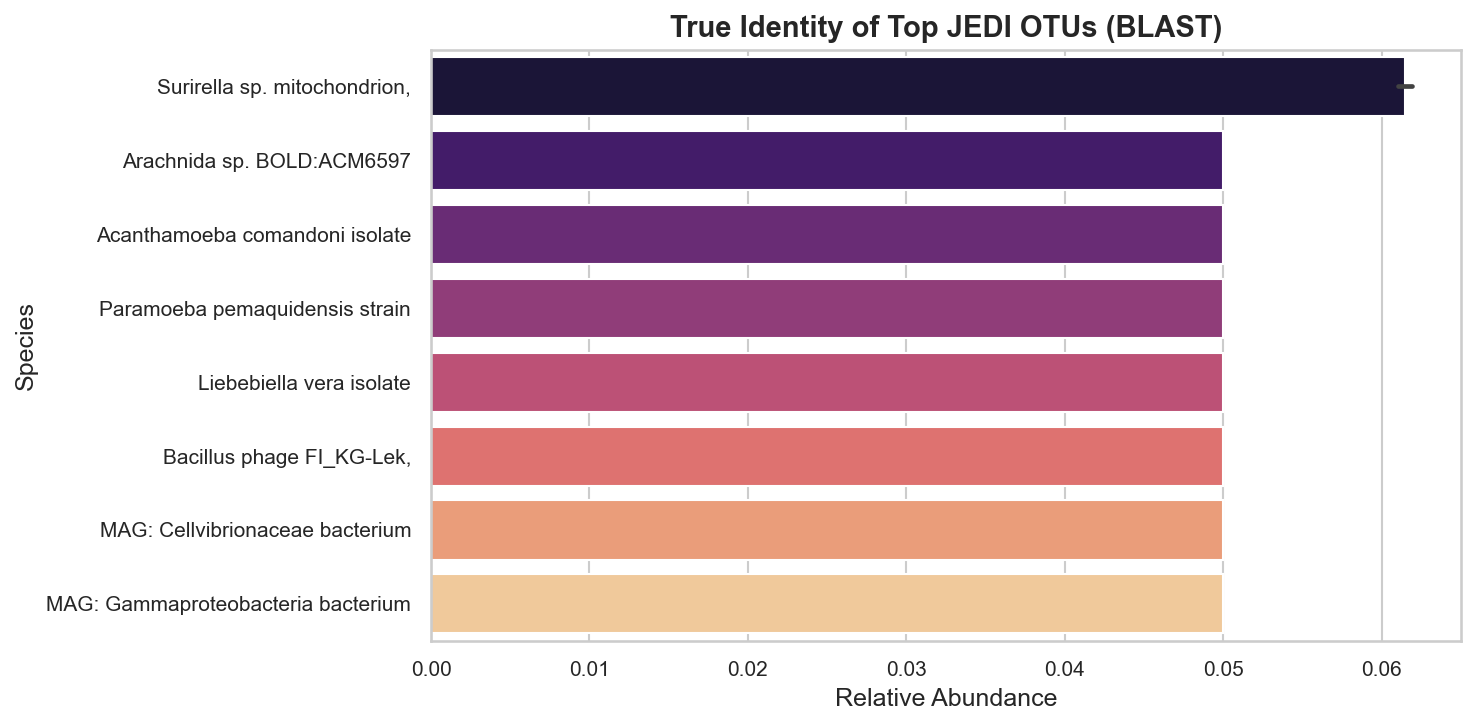

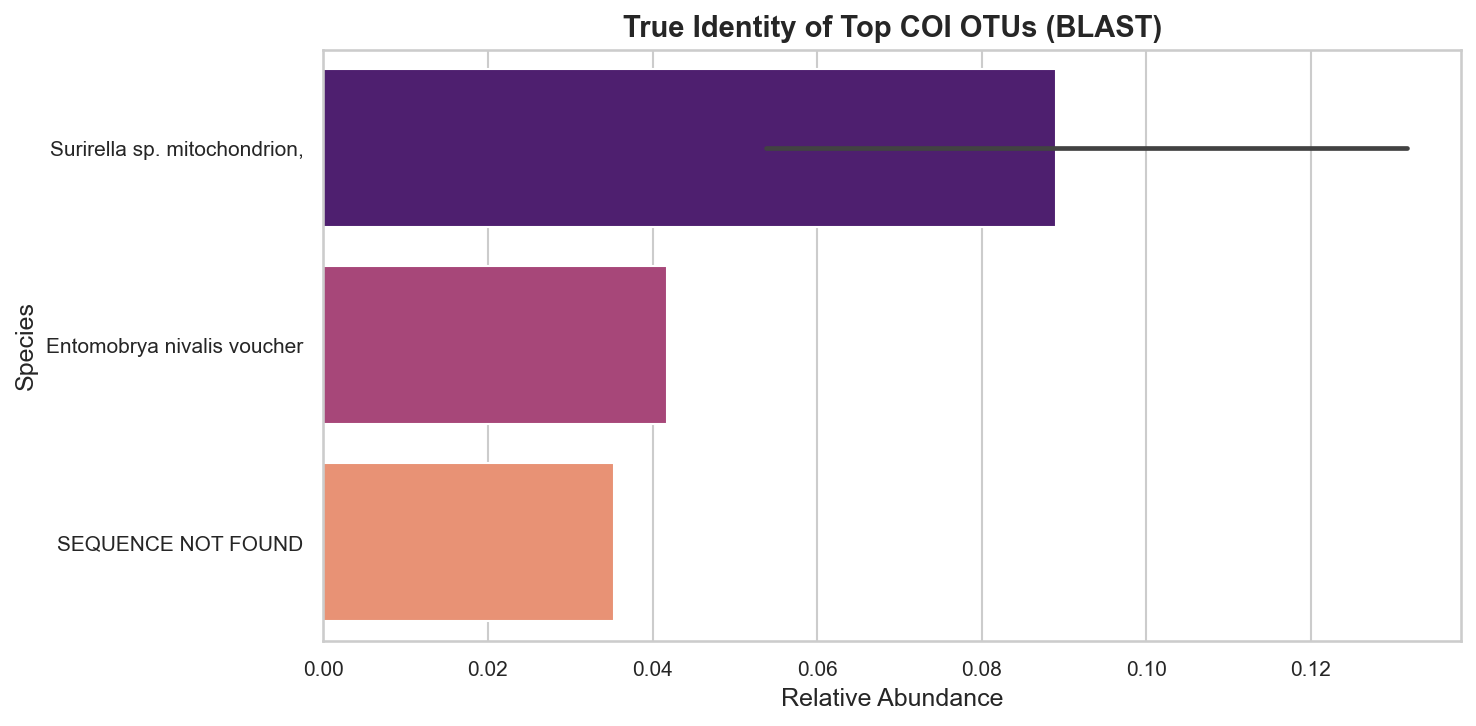

In [26]:
def parse_blast_file(filepath):
    """Parses the custom text output from script 6_blast_top_otus.py"""
    data = []
    try:
        with open(filepath, 'r') as f:
            lines = f.readlines()

        start_reading = False
        for line in lines:
            if line.startswith('---'):
                start_reading = True
                continue
            if not start_reading or not line.strip(): continue

            parts = line.split('|')
            if len(parts) >= 3:
                species = parts[2].strip()
                if "Uncultured" in species: species = "Uncultured organism"
                try:
                    reads = float(parts[1].strip())
                    data.append({'Species': species, 'Abundance': reads})
                except: continue
    except FileNotFoundError:
        print("BLAST file not found.")
        return pd.DataFrame()

    return pd.DataFrame(data)

# Load and Plot BLAST results for both markers
for marker in ['JEDI', 'COI']:
    df_blast = parse_blast_file(f'out/Soil_eDNA_JEDI_COI_14_01_26/blast_results/blast_top10_{marker}.txt')
    if not df_blast.empty:
        plt.figure(figsize=(10, 5))
        sns.barplot(data=df_blast, y='Species', x='Abundance', hue='Species', palette='magma', legend=False)
        plt.title(f'True Identity of Top {marker} OTUs (BLAST)', fontweight='bold')
        plt.xlabel('Relative Abundance')
        plt.tight_layout()
        plt.show()
    else:
        print(f"No valid BLAST data found for {marker}.")

---
## Part C: Computational Costs
**Summary:**
* **Bottleneck:** The clustering step (Step 3) is expected to dominate the total runtime due to the $N \times N$ comparison.
* **JEDI vs COI:** Processing time may differ between markers depending on the number of reads that pass quality filters.

Update the timing values below from the pipeline log after running: `out/logs/pipeline_*.log` → "GLOBAL PIPELINE STEPS TIMING" section.

In [27]:
# UPDATE THESE VALUES from your pipeline log after running on soil data
# Check: out/logs/pipeline_*.log → "GLOBAL PIPELINE STEPS TIMING" section
timing_data = {
    'Step': [
        '1. Preprocessing (QC)',
        '2. Marker Classification',
        '3. Clustering (JEDI + COI)',
        '4. Matrix Merging',
        '5. Taxonomy Assignment',
        '6. BLAST Validation',
        '7. Summary Generation'
    ],
    'Time_Seconds': [
        0,    # Preprocessing — update after run
        0,    # Classification
        0,    # Clustering (The bottleneck!)
        0,    # Merging
        0,    # Taxonomy
        0,    # BLAST
        0     # Summary
    ]
}

df_time = pd.DataFrame(timing_data)

if df_time['Time_Seconds'].sum() > 0:
    total_time = df_time['Time_Seconds'].sum()
    df_time['Percentage'] = (df_time['Time_Seconds'] / total_time) * 100

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = sns.barplot(x='Time_Seconds', y='Step', data=df_time, hue='Step', palette='Blues_r', ax=ax, legend=False)

    for i, v in enumerate(df_time['Time_Seconds']):
        pct = df_time.loc[i, 'Percentage']
        ax.text(v + 10, i, f"{int(v)}s ({pct:.1f}%)", va='center', fontweight='bold')

    ax.set_title(f'Pipeline Runtime Distribution (Total: {total_time/60:.0f} min)', fontweight='bold')
    ax.set_xlabel('Time (Seconds)')
    ax.set_ylabel('Pipeline Step')
    ax.grid(axis='x', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()
else:
    print("Pipeline not run yet. Update the 'timing_data' dict above with actual timing from the log.")

Pipeline not run yet. Update the 'timing_data' dict above with actual timing from the log.


---
# Part D: Methodological Defense & Improvements

### 1. Error Correction Strategy
* **Problem:** Nanopore sequencing has a raw error rate of ~5-10%.
* **Solution:** We used **95% Identity Clustering**.
    * *Why?* Clustering at 97% or 99% (typical for Illumina) would have resulted in many false OTUs because every sequencing error would look like a new species.

### 2. Size Selection
* **JEDI Filter:** Reads were filtered for ~300–600 bp (target region ~460 bp). Reads outside this range are likely primer-dimers or concatemers.
* **COI Filter:** Reads were filtered for ~500–800 bp (target region ~658 bp). The stricter length requirement may explain lower COI yield in degraded soil DNA.

### 3. JEDI vs COI: Marker Choice for Soil
* **JEDI Advantage:** The shorter ~460 bp fragment is better suited for degraded soil DNA, where humic acids cause fragmentation.
* **COI Advantage:** The longer ~658 bp fragment may provide better species-level resolution when DNA quality is sufficient.
* **Recommendation:** For routine soil monitoring with Nanopore, JEDI is likely the more robust choice.

### 4. Critical Requirement: Custom Reference Database
* **The Problem:** We relied on the general-purpose MIDORI2 COI database, which lacks many local Swiss soil invertebrates.
* **The Solution (Future Work):** Build a **"Swiss Soil Fauna"** reference database by downloading COI sequences of known local species from NCBI and formatting them for SINTAX.
* **Benefit:** This would eliminate database-artifact misidentifications and allow accurate species-level identification of local soil biodiversity.

### 5. Computational Cost Optimization
* **Bottleneck:** The VSEARCH clustering step ($N \times N$ comparison) dominates runtime.